In [2]:
import os
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib 
import seaborn as sns
import sys
sys.path.insert(0, '../../src')
import utils

In [3]:
# ── Configure ──────────────────────────────────────────────────────────────────
results_path = '../../outputs/costly/mdp_output/optimal_subsidy_results.pt'
# ──────────────────────────────────────────────────────────────────────────────

res    = torch.load(results_path, weights_only=False)
params = res['params']

epsilons         = res['epsilons']           # partition breakpoints (sorted)
social_utilities = res['social_utilities']   # U^S at each breakpoint
eps_star         = res['eps_star']
us_star          = res['us_star']
P_list           = res['P_per_breakpoint']   # approval prob under pi_i
A_list           = res['A_per_breakpoint']   # E[cost | approval] under pi_i

rho_S       = float(params['rho_S'])
epsilon_max = float(params['epsilon_max'])
c0         = float(params['c0'])
c1         = float(params['c1'])


#print parameters
print("Parameters:")
print(f"rho_S: {rho_S}")
print(f"epsilon_max: {epsilon_max}")
print(f"rho_A: {params['rho_A']}")
print(f"c0: {c0}")
print(f"c1: {c1}")


print(f"Partition ({len(epsilons)} breakpoints):")
print(f"{'eps_i':>12}  {'U^S':>10}  {'P_i':>8}  {'A_i':>8}")
for eps, us, p, a in zip(epsilons, social_utilities, P_list, A_list):
    marker = ' <-- eps*' if abs(eps - eps_star) < 1e-9 else ''
    print(f"{eps:12.8f}  {us:10.4f}  {p:8.4f}  {a:8.2f}{marker}")

Parameters:
rho_S: 2000.0
epsilon_max: 0.9
rho_A: 240
c0: 100.0
c1: 0.1
Partition (18 breakpoints):
       eps_i         U^S       P_i       A_i
  0.00000000      0.0000    0.0000      0.00
  0.55112414    730.0767    0.3773     44.50 <-- eps*
  0.58520444    728.6101    0.3773     44.52
  0.60416667    727.7669    0.3773     44.52
  0.63828963    726.5402    0.3775     44.58
  0.64822622    726.2202    0.3776     44.65
  0.65700553    726.0896    0.3777     44.70
  0.74883359    722.0192    0.3778     44.71
  0.75379939    721.8677    0.3778     44.73
  0.75770925    721.6990    0.3778     44.73
  0.76430650    721.4179    0.3778     44.73
  0.77037037    721.1601    0.3778     44.74
  0.78386579    720.7462    0.3779     44.78
  0.79092791    720.6122    0.3780     44.82
  0.82737643    718.9967    0.3780     44.83
  0.83076389    719.1764    0.3783     45.09
  0.85350679    718.2589    0.3784     45.12
  0.88014827    717.1515    0.3784     45.14


In [4]:
# ── Build piecewise-linear social utility curve ────────────────────────────────
#
# Within interval [eps_i, eps_{i+1}), policy pi_i is optimal and
#   U^S(eps; pi_i) = rho_S * P_i - eps * A_i   (Eq. 18, point-mass Q)

N_SAMPLE = 300  # points per segment

segments = []   # list of (eps_array, us_array, interval_label)

for i in range(len(epsilons)):
    eps_left  = epsilons[i]
    eps_right = epsilons[i + 1] if i + 1 < len(epsilons) else epsilon_max
    P_i, A_i = P_list[i], A_list[i]

    eps_seg = np.linspace(eps_left, eps_right, N_SAMPLE)
    us_seg  = rho_S * P_i - eps_seg * A_i
    label   = f'$\\pi_{{{i}}}$\ ($\\varepsilon\\in [{eps_left:.3f},\ {eps_right:.3f})$)'
    segments.append((eps_seg, us_seg, label))

<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2960883/81775659.py:17: SyntaxWarning: invalid escape sequence '\ '
  label   = f'$\\pi_{{{i}}}$\ ($\\varepsilon\\in [{eps_left:.3f},\ {eps_right:.3f})$)'
/tmp/ipykernel_2960883/81775659.py:17: SyntaxWarning: invalid escape sequence '\ '
  label   = f'$\\pi_{{{i}}}$\ ($\\varepsilon\\in [{eps_left:.3f},\ {eps_right:.3f})$)'


In [5]:
#For any epsilon, print the initial optimal action

policy_list = res['policy_per_breakpoint']

print(f"{'Epsilon interval':<30} {'Initial action':>15}")
print('-' * 47)
for i, (eps, pol) in enumerate(zip(epsilons, policy_list)):
    eps_next = epsilons[i + 1] if i + 1 < len(epsilons) else epsilon_max
    initial_action = int(pol[0][0, 0])  # l=0, N=0, X=0
    action_str = str(initial_action) if initial_action > 0 else 'opt-out (0)'
    print(f'[{eps:.6f}, {eps_next:.6f})     {action_str:>15}')


Epsilon interval                Initial action
-----------------------------------------------
[0.000000, 0.551124)         opt-out (0)
[0.551124, 0.585204)                  79
[0.585204, 0.604167)                  79
[0.604167, 0.638290)                  79
[0.638290, 0.648226)                  79
[0.648226, 0.657006)                  79
[0.657006, 0.748834)                  79
[0.748834, 0.753799)                  79
[0.753799, 0.757709)                  79
[0.757709, 0.764306)                  79
[0.764306, 0.770370)                  79
[0.770370, 0.783866)                  79
[0.783866, 0.790928)                  79
[0.790928, 0.827376)                  79
[0.827376, 0.830764)                  79
[0.830764, 0.853507)                  79
[0.853507, 0.880148)                  79
[0.880148, 0.900000)                  79


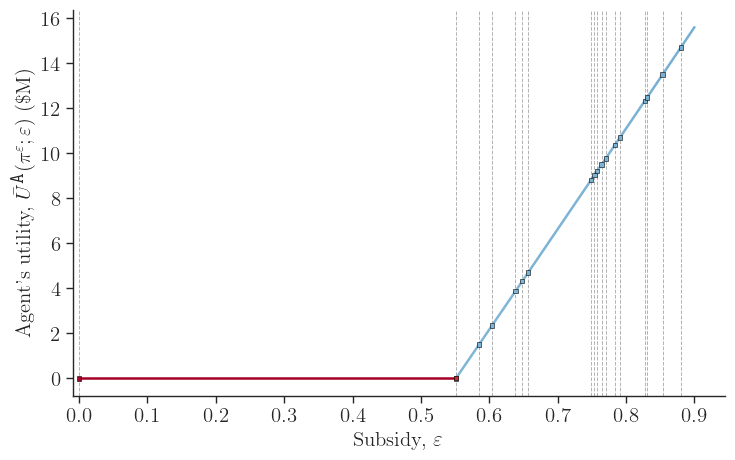

Saved to ../../figures/costly/mdp_output/agent_value_vs_epsilon.pdf


In [22]:
# ── Agent's optimal value function V*(eps) = V0_i + eps * A_i ─────────────────
#
# Within interval [eps_i, eps_{i+1}), policy pi_i is optimal and
#   V*(eps) = V^0_i + eps * A_i   (Proposition 7)
# The upper envelope of these linear functions is piecewise linear and convex
# (Proposition 8).
#
# Plotted on a symlog y-axis: linear near zero, logarithmic for large |values|.
# This handles the case where V*(0) < 0 (agent opts out without subsidy).

V0_list = res['V0_per_breakpoint']

sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 1000

fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

import matplotlib.colors as _mcolors
import matplotlib.cm as _cm
_cmap_v    = matplotlib.colormaps['RdYlBu_r']
_norm_v    = _mcolors.Normalize(vmin=min(true_optout_list), vmax=max(true_optout_list))
_norm_v = _mcolors.Normalize(vmin=0.0, vmax=1.0)
seg_colors = [_cmap_v(_norm_v(p)) for p in true_optout_list]
palette    = sns.color_palette('tab10')

all_v = []
for i in range(len(epsilons)):
    eps_left  = epsilons[i]
    eps_right = epsilons[i + 1] if i + 1 < len(epsilons) else epsilon_max
    V0_i, A_i = V0_list[i], A_list[i]
    eps_seg = np.linspace(eps_left, eps_right, N_SAMPLE)
    v_seg   = V0_i + eps_seg * A_i
    all_v.extend(v_seg)
    label   = f'$\\pi_{{{i}}}$\\ ($\\varepsilon\\in [{eps_left:.3f},\\ {eps_right:.3f})$)'
    ax.plot(eps_seg, v_seg, color=seg_colors[i], lw=1.8, label=label)

# symlog threshold: use 1% of the max absolute value so the linear region is narrow
linthresh = max(1e-3, 0.01 * np.max(np.abs(all_v)))
#ax.set_yscale('symlog', linthresh=linthresh)


# Vertical dashed lines at each partition breakpoint
for eps_i in epsilons:
    ax.axvline(eps_i, color='gray', lw=0.7, ls='--', alpha=0.6)

# Kink points: V*(eps_i) = V0_i + eps_i * A_i
kink_values = [V0_list[i] + epsilons[i] * A_list[i] for i in range(len(epsilons))]
ax.scatter(epsilons, kink_values,
           color=[seg_colors[i] for i in range(len(epsilons))],
           s=10, zorder=5, edgecolors='black', linewidths=0.4, marker='s')

# Mark eps*
star_idx = epsilons.index(eps_star)
v_star = V0_list[star_idx] + eps_star * A_list[star_idx]


ax.scatter([eps_star], [v_star], color=palette[3], s=10, zorder=6,
           edgecolors='black', linewidths=0.4, marker='s')

# Partition breakpoints as x-axis ticks
ax.set_xticks(epsilons)


ax.set_xlabel(r'Subsidy, $\varepsilon$', fontsize=15)
ax.set_ylabel(r"Agent's utility, $\bar{U}^{\texttt{A}}(\pi^{\varepsilon};\varepsilon)$ (\$M)", fontsize=15)


ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)

_step   = 0.1
_xticks = np.arange(0.0, epsilon_max + _step, _step)
_xticks = _xticks[_xticks <= epsilon_max + 1e-9]
ax.set_xticks(_xticks)
ax.set_xticklabels([f'{t:.1f}' for t in _xticks], fontsize=15)
ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)

ax.tick_params(axis='y', labelsize=15)


# _sm_v = _cm.ScalarMappable(cmap=_cmap_v, norm=_norm_v)
# _sm_v.set_array([])
# _cb_v = fig.colorbar(_sm_v, ax=ax, pad=0.02, fraction=0.03)
# _cb_v.set_label(r'Probability of opting out', fontsize=15)
# _cb_v.ax.tick_params(labelsize=9)

sns.despine()
plt.tight_layout()
plt.show()

os.makedirs('../../figures/costly/mdp_output', exist_ok=True)
fig.savefig('../../figures/costly/mdp_output/agent_value_vs_epsilon.pdf',
            format='pdf', bbox_inches='tight')
print('Saved to ../../figures/costly/mdp_output/agent_value_vs_epsilon.pdf')

NameError: name 'true_optout_list' is not defined

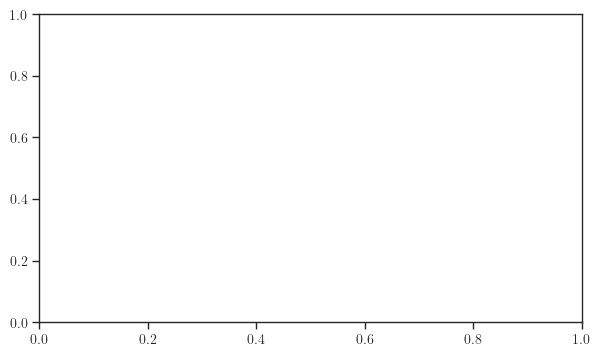

In [7]:
# Plot E[cost | approval] (A_i) vs subsidy breakpoint (epsilon_i)
#
# A_i = E[C | approved, pi_i] is the expected experiment cost under policy pi_i,
# conditioned on the agent being approved (i.e. passing the experiment).
# epsilons are the partition breakpoints of the optimal subsidy grid.
#
# This plot reveals how the conditional cost changes across intervals:
# a rising A_i means higher-subsidy policies induce costlier (but more informative)
# experiments conditional on approval.

import matplotlib.colors as _mcolors
import matplotlib.cm as _cm

fig, ax = plt.subplots(figsize=(7, 4))

_cmap_a       = matplotlib.colormaps['RdYlBu_r']
_norm_a       = _mcolors.Normalize(vmin=min(true_optout_list), vmax=max(true_optout_list))
_seg_colors_a = [_cmap_a(_norm_a(p)) for p in true_optout_list]

for i in range(len(epsilons)):
    eps_left  = epsilons[i]
    eps_right = epsilons[i + 1] if i + 1 < len(epsilons) else epsilon_max
    ax.hlines(A_list[i], eps_left, eps_right, colors=_seg_colors_a[i], linewidth=2.0, zorder=2)
    ax.scatter([eps_left], [A_list[i]], color=_seg_colors_a[i], s=10, zorder=5,
               edgecolors='black', linewidths=0.4, marker='s')

# Partition verticals
for eps_i in epsilons:
    ax.axvline(eps_i, color='gray', lw=0.5, ls='--', alpha=0.8)

ax.set_xlabel(r'Subsidy, $\varepsilon$', fontsize=15)
ax.set_ylabel(r'Expected approval cost', fontsize=15)

_step   = 0.1
_xticks = np.arange(0.0, epsilon_max + _step, _step)
_xticks = _xticks[_xticks <= epsilon_max + 1e-9]
ax.set_xticks(_xticks)
ax.set_xticklabels([f'{t:.1f}' for t in _xticks], fontsize=15)
ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)

#Set yticks fontsize
ax.tick_params(axis='y', labelsize=15)

#ax.grid(True, linestyle='--', alpha=0.4)

_sm_a = _cm.ScalarMappable(cmap=_cmap_a, norm=_norm_a)
_sm_a.set_array([])
_cb_a = fig.colorbar(_sm_a, ax=ax, pad=0.02, fraction=0.03)
_cb_a.set_label(r'Probability of opting out', fontsize=15)
_cb_a.ax.tick_params(labelsize=9)

sns.despine()
plt.tight_layout()
plt.show()

fig.savefig('../../figures/costly/mdp_output/approval_cost_vs_epsilon.pdf', dpi=300,   format='pdf', bbox_inches='tight')

MC opt-out (MDP Beta-Binomial dynamics): 200,000 episodes per policy

  [ 0] eps=0.000000  P(opt-out before approval | MDP) = 1.0000
  [ 1] eps=0.551124  P(opt-out before approval | MDP) = 0.6201
  [ 2] eps=0.585204  P(opt-out before approval | MDP) = 0.6200
  [ 3] eps=0.604167  P(opt-out before approval | MDP) = 0.6200
  [ 4] eps=0.638290  P(opt-out before approval | MDP) = 0.6198
  [ 5] eps=0.648226  P(opt-out before approval | MDP) = 0.6194
  [ 6] eps=0.657006  P(opt-out before approval | MDP) = 0.6191
  [ 7] eps=0.748834  P(opt-out before approval | MDP) = 0.6190
  [ 8] eps=0.753799  P(opt-out before approval | MDP) = 0.6189
  [ 9] eps=0.757709  P(opt-out before approval | MDP) = 0.6189
  [10] eps=0.764306  P(opt-out before approval | MDP) = 0.6188
  [11] eps=0.770370  P(opt-out before approval | MDP) = 0.6188
  [12] eps=0.783866  P(opt-out before approval | MDP) = 0.6186
  [13] eps=0.790928  P(opt-out before approval | MDP) = 0.6185
  [14] eps=0.827376  P(opt-out before approval |

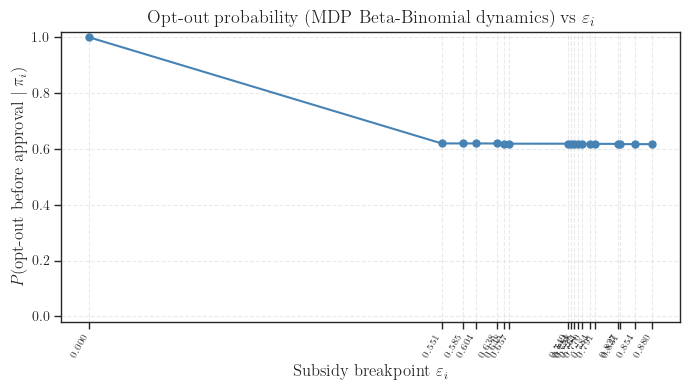

In [8]:
# ── Opt-out probability before approval: MDP belief dynamics (Beta-Binomial) ──
#
# For each partition interval [eps_i, eps_{i+1}), policy pi_i is optimal.
# We estimate:
#
#   p_out_i = P(agent opts out before approval | pi_i, MDP dynamics)
#
# The MDP's outcome distribution at each step is the Beta-Binomial with the
# CURRENT posterior: x_t | n_t, (N, X) ~ BetaBinomial(n_t, alpha_0+X, beta_0+N-X).
# (See MDP_solver.py: alpha_ch = alpha_0 + X_chunk, beta_ch = beta_0 + N_chunk - X_exp.)
# This is implemented by drawing theta ~ Beta(alpha_0+X, beta_0+N-X) freshly at
# every stage — NOT a single draw from the prior at episode start.
#
# ── Configure ──────────────────────────────────────────────────────────────────
n_ep_optout  = 200_000
seed_optout  = 0
# ──────────────────────────────────────────────────────────────────────────────

def _mc_optout_mdp(policy, params, n_episodes, seed):
    """
    MC opt-out probability under MDP belief dynamics (Beta-Binomial).

    At each stage, draws theta ~ Beta(alpha_0 + X, beta_0 + N - X) using the
    current posterior, then draws x ~ Binomial(n, theta).  This matches the
    BetaBinomial transition kernel used in MDP_solver.py exactly.
    Returns p_optout = P(agent selects n=0 at some stage l before approval).
    """
    rng           = np.random.default_rng(seed)
    T             = int(params['T'])
    alpha_0       = float(params['alpha_0'])
    beta_0        = float(params['beta_0'])
    log_kappa_inv = np.log(1.0 / float(params['kappa']))
    log_term      = np.log(1.0 + float(params['theta_b']) * (np.e - 1.0))

    def _approved(N, X):
        alpha = alpha_0 + X
        beta  = beta_0  + N - X
        return (alpha - alpha_0) - (alpha + beta - alpha_0 - beta_0) * log_term >= log_kappa_inv

    n_optout = 0
    for _ in range(n_episodes):
        N, X      = 0, 0
        opted_out = False
        for l in range(T + 1):
            n_star = int(policy[l][N, X])
            if n_star == 0:
                opted_out = True
                break
            # Draw from current posterior predictive (matches MDP_solver.py kernel)
            theta = rng.beta(alpha_0 + X, beta_0 + N - X)
            x     = int(rng.binomial(n_star, theta))
            N    += n_star;  X += x
            if _approved(N, X):
                break           # approved — not an opt-out
        if opted_out:
            n_optout += 1

    return n_optout / n_episodes


print(f"MC opt-out (MDP Beta-Binomial dynamics): {n_ep_optout:,} episodes per policy\n")
policy_per_bp_list = res['policy_per_breakpoint']

mdp_optout_list = []
for i, (eps_i, policy) in enumerate(zip(epsilons, policy_per_bp_list)):
    p_out = _mc_optout_mdp(policy, params, n_ep_optout, seed_optout)
    mdp_optout_list.append(p_out)
    print(f"  [{i:2d}] eps={eps_i:.6f}  P(opt-out before approval | MDP) = {p_out:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epsilons, mdp_optout_list, 'o-', color='steelblue', linewidth=1.5, markersize=5)
ax.set_xlabel(r'Subsidy breakpoint $\varepsilon_i$', fontsize=12)
ax.set_ylabel(r'$P(\mbox{opt-out before approval} \mid \pi_i)$', fontsize=12)
ax.set_title(
    r'Opt-out probability (MDP Beta-Binomial dynamics) vs $\varepsilon_i$',
    fontsize=13
)
ax.set_xticks(epsilons)
ax.set_xticklabels([f'{e:.3f}' for e in epsilons], rotation=60, ha='right', fontsize=7)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


MC opt-out (true theta*=0.65): 200,000 episodes per policy

  [ 0] eps=0.000000  P_true(opt-out before approval) = 1.0000
  [ 1] eps=0.551124  P_true(opt-out before approval) = 0.2210
  [ 2] eps=0.585204  P_true(opt-out before approval) = 0.2205
  [ 3] eps=0.604167  P_true(opt-out before approval) = 0.2205
  [ 4] eps=0.638290  P_true(opt-out before approval) = 0.2183
  [ 5] eps=0.648226  P_true(opt-out before approval) = 0.2189
  [ 6] eps=0.657006  P_true(opt-out before approval) = 0.2171
  [ 7] eps=0.748834  P_true(opt-out before approval) = 0.2166
  [ 8] eps=0.753799  P_true(opt-out before approval) = 0.2173
  [ 9] eps=0.757709  P_true(opt-out before approval) = 0.2172
  [10] eps=0.764306  P_true(opt-out before approval) = 0.2171
  [11] eps=0.770370  P_true(opt-out before approval) = 0.2169
  [12] eps=0.783866  P_true(opt-out before approval) = 0.2150
  [13] eps=0.790928  P_true(opt-out before approval) = 0.2133
  [14] eps=0.827376  P_true(opt-out before approval) = 0.2130
  [15] eps

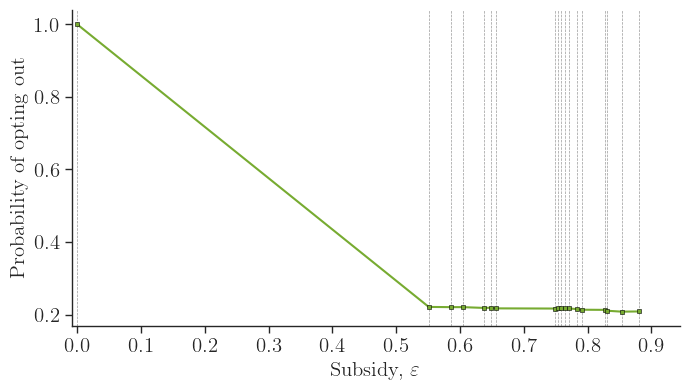

In [9]:
# ── Opt-out probability before approval: true dynamics (theta_star) ─────────────
#
# Same rollout as above but outcomes are drawn from Binomial(n, theta_star) — the
# true data-generating process.  This gives the TRUE probability that the agent
# opts out before approval for each optimal policy pi_i.
#
# Requires theta_star from the config (same source as cell 6).
#
# ── Configure ──────────────────────────────────────────────────────────────────
import yaml
config_path    = '../../config/costly.yaml'
n_ep_true_out  = 200_000
seed_true_out  = 1
# ──────────────────────────────────────────────────────────────────────────────

with open(config_path) as f:
    _cfg_out = yaml.safe_load(f)
theta_star_out = float(_cfg_out['theta_star'])

def _mc_optout_true(policy, theta_star, params, n_episodes, seed):
    """
    MC opt-out probability under true dynamics (Binomial with fixed theta_star).
    Returns p_optout = P_theta*(agent selects n=0 at some l before approval).
    """
    rng           = np.random.default_rng(seed)
    T             = int(params['T'])
    alpha_0       = float(params['alpha_0'])
    beta_0        = float(params['beta_0'])
    log_kappa_inv = np.log(1.0 / float(params['kappa']))
    log_term      = np.log(1.0 + float(params['theta_b']) * (np.e - 1.0))

    def _approved(N, X):
        alpha = alpha_0 + X
        beta  = beta_0  + N - X
        return (alpha - alpha_0) - (alpha + beta - alpha_0 - beta_0) * log_term >= log_kappa_inv

    n_optout = 0
    for _ in range(n_episodes):
        N, X      = 0, 0
        opted_out = False
        for l in range(T + 1):
            n_star = int(policy[l][N, X])
            if n_star == 0:
                opted_out = True
                break
            x  = int(rng.binomial(n_star, theta_star))
            N += n_star;  X += x
            if _approved(N, X):
                break           # approved — not an opt-out
        if opted_out:
            n_optout += 1

    return n_optout / n_episodes


print(f"MC opt-out (true theta*={theta_star_out}): {n_ep_true_out:,} episodes per policy\n")

true_optout_list = []
for i, (eps_i, policy) in enumerate(zip(epsilons, policy_per_bp_list)):
    p_out = _mc_optout_true(policy, theta_star_out, params, n_ep_true_out, seed_true_out)
    true_optout_list.append(p_out)
    print(f"  [{i:2d}] eps={eps_i:.6f}  P_true(opt-out before approval) = {p_out:.4f}")

palette = sns.color_palette('husl', 10)

fig, ax = plt.subplots(figsize=(7, 4))


#ax.plot(epsilons, true_optout_list, 's-', color=palette[3], linewidth=1.5, markersize=2, markeredgecolor='black', markeredgewidth=0.4)
# Line
ax.plot(
    epsilons,
    true_optout_list,
    '-',
    color=palette[3],
    linewidth=1.5
)

# Markers (IDENTICAL STYLE)
ax.scatter(
    epsilons,
    true_optout_list,
    s=10,
    color=palette[3],
    edgecolors='black',
    linewidths=0.4,
    marker='s',
    zorder=5
)


ax.set_xlabel(r'Subsidy breakpoint $\varepsilon_i$', fontsize=12)
ax.set_ylabel(r'$P_{{\theta^*}}(\mbox{{opt-out before approval}} \mid \pi_i)$', fontsize=12)

# Partition verticals
for eps_i in epsilons:
    ax.axvline(eps_i, color='gray', lw=0.5, ls='--', alpha=0.8)

ax.set_xlabel(r'Subsidy, $\varepsilon$', fontsize=15)
ax.set_ylabel(r'Probability of opting out', fontsize=15)

_step   = 0.1
_xticks = np.arange(0.0, epsilon_max + _step, _step)
_xticks = _xticks[_xticks <= epsilon_max + 1e-9]
ax.set_xticks(_xticks)
ax.set_xticklabels([f'{t:.1f}' for t in _xticks], fontsize=15)
ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)

#Set yticks fontsize
ax.tick_params(axis='y', labelsize=15)
#ax.set_ylim(-0.02, 1.02)
#ax.grid(True, linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig('../../figures/costly/mdp_output/true_optout_vs_epsilon.pdf', dpi=300, format='pdf', bbox_inches='tight')

In [10]:
# ── Diagnosing the opt-out probability jump at eps ≈ 0.108 ───────────────────
#
# The true opt-out probability drops sharply between eps_10 = 0.0989 and
# eps_11 = 0.1079 (eps*).  Here we identify exactly which policy change drives it.

import yaml
from scipy.stats import binom as sp_binom, betabinom as sp_betabinom

with open('../../config/costly.yaml') as f:
    _cfg_diag = yaml.safe_load(f)
_theta_star_diag = float(_cfg_diag['theta_star'])

_alpha_0       = float(params['alpha_0'])
_beta_0        = float(params['beta_0'])
_n_max         = int(params['n_max'])
_T             = int(params['T'])
_kappa         = float(params['kappa'])
_theta_b       = float(params['theta_b'])
_log_kappa_inv = np.log(1.0 / _kappa)
_log_term      = np.log(1.0 + _theta_b * (np.e - 1.0))

def _is_approved(N, X):
    a = _alpha_0 + X;  b = _beta_0 + N - X
    return (a - _alpha_0) - (a + b - _alpha_0 - _beta_0) * _log_term >= _log_kappa_inv

# ── 1.  Enumerate all policy differences around the jump ─────────────────────
i_before, i_after = 10, 11
eps_before = epsilons[i_before]
eps_after  = epsilons[i_after]
pol_before = policy_per_bp_list[i_before]
pol_after  = policy_per_bp_list[i_after]

print(f"Comparing policies:")
print(f"  BEFORE : eps = {eps_before:.6f}  (index {i_before})")
print(f"  AFTER  : eps = {eps_after:.6f}  (index {i_after}, eps*)")
print()

for l in range(_T + 1):
    max_N = l * _n_max
    opt_in, opt_out, n_to_m = [], [], []
    for N in range(max_N + 1):
        for X in range(N + 1):
            nb = int(pol_before[l][N, X]);  na = int(pol_after[l][N, X])
            if nb == na: continue
            if   nb == 0: opt_in.append((N, X, nb, na))
            elif na == 0: opt_out.append((N, X, nb, na))
            else:         n_to_m.append((N, X, nb, na))
    total = len(opt_in) + len(opt_out) + len(n_to_m)
    if total:
        print(f"l={l}: {len(opt_in)} newly opt-IN (0->n),  "
              f"{len(opt_out)} newly opt-OUT (n->0),  "
              f"{len(n_to_m)} n-size shifts (n->m)")

# ── 2.  Identify the reachable change ────────────────────────────────────────
print()
print("=" * 65)
print("THE KEY CHANGE")
print("=" * 65)
n0 = int(pol_before[0][0, 0])
print(f"l=0, (N=0,X=0): n* = {n0}  (same in both policies)")
print()
print(f"After l=0 (n={n0} trials) we land at (N={n0}, X) for X in [0,{n0}].")
print(f"Policy at ({n0}, X) near the opt-out boundary:")
print(f"  {'X':>4}  {'approved':>9}  {'n_before':>9}  {'n_after':>8}  {'post_mean':>10}  note")
for X in range(40, 56):
    nb  = int(pol_before[1][n0, X]);  na = int(pol_after[1][n0, X])
    app = _is_approved(n0, X)
    bm  = (_alpha_0 + X) / (_alpha_0 + _beta_0 + n0)
    tag = "  *** NEW OPT-IN ***" if nb == 0 and na > 0 else ("  (approved)" if app else "")
    print(f"  {X:4d}  {str(app):>9}  {nb:9d}  {na:8d}  {bm:10.4f}{tag}")

# ── 3.  Why the true dynamics drop more than MDP ─────────────────────────────
print()
print("=" * 65)
print("WHY THE TRUE DYNAMICS SHOW A BIGGER DROP")
print("=" * 65)
p_true = sp_binom.pmf(47, n0, _theta_star_diag)
p_mdp  = sp_betabinom.pmf(47, n0, _alpha_0, _beta_0)   # = 1/(n0+1) for Uniform prior

print(f"\nProbability of reaching state (N={n0}, X=47) at l=1:")
print(f"  Under theta* = {_theta_star_diag} (true):     P = Bin({n0}, 47, {_theta_star_diag}) = {p_true:.4f}")
print(f"  Under MDP prior Beta(1,1):        P = BetaBin({n0}, 47, 1, 1) = {p_mdp:.4f}  [= 1/{n0+1}]")
print(f"\n  => (N={n0}, X=47) is {p_true/p_mdp:.1f}x more likely under true dynamics.")
print(f"     Switching this state from opt-out to opt-in therefore causes a")
print(f"     {p_true/p_mdp:.1f}x larger drop in true opt-out probability vs MDP opt-out probability.")

# ── 4.  Interpretation ────────────────────────────────────────────────────────
print()
print("=" * 65)
print("INTERPRETATION")
print("=" * 65)
bm_47    = (_alpha_0 + 47) / (_alpha_0 + _beta_0 + n0)
hit_rate = 47 / n0
exp_X    = _theta_star_diag * n0
print(f"\nAfter {n0} trials with 47 successes (empirical hit rate = {hit_rate:.3f}):")
print(f"  Posterior mean = {bm_47:.4f}  (below theta* = {_theta_star_diag})")
print()
print(f"  At eps < eps* = {eps_after:.4f}:  agent OPTS OUT — the subsidy does not cover the")
print(f"    expected cost of 179 more trials given this lukewarm evidence.")
print()
print(f"  At eps >= eps* = {eps_after:.4f}: agent CONTINUES with n=179 more trials —")
print(f"    the higher subsidy just tips the indifference condition.")
print()
print(f"This is the single reachable newly-crossed opt-in state across all l, N, X.")
print()
print(f"Under theta* = {_theta_star_diag}, the expected successes after {n0} trials is {exp_X:.1f},")
print(f"so X=47 is only ~{exp_X-47:.0f} below expectation and occurs with probability {p_true:.3f}.")
print(f"Under the flat BetaBinomial prior it has probability {p_mdp:.3f} (= 1/{n0+1} by symmetry).")
print(f"This {p_true/p_mdp:.1f}x difference in visitation frequency is why the TRUE opt-out")
print(f"curve shows a much sharper cliff than the MDP-dynamics curve at this breakpoint.")


Comparing policies:
  BEFORE : eps = 0.764306  (index 10)
  AFTER  : eps = 0.770370  (index 11, eps*)

l=1: 5 newly opt-IN (0->n),  0 newly opt-OUT (n->0),  42 n-size shifts (n->m)
l=2: 20 newly opt-IN (0->n),  0 newly opt-OUT (n->0),  34 n-size shifts (n->m)
l=3: 26 newly opt-IN (0->n),  0 newly opt-OUT (n->0),  23 n-size shifts (n->m)

THE KEY CHANGE
l=0, (N=0,X=0): n* = 79  (same in both policies)

After l=0 (n=79 trials) we land at (N=79, X) for X in [0,79].
Policy at (79, X) near the opt-out boundary:
     X   approved   n_before   n_after   post_mean  note
    40      False          0         0      0.5062
    41      False          0         0      0.5185
    42      False          0         0      0.5309
    43      False          0         0      0.5432
    44      False          0         0      0.5556
    45      False          0         0      0.5679
    46      False          0         0      0.5802
    47      False          0         0      0.5926
    48      False      

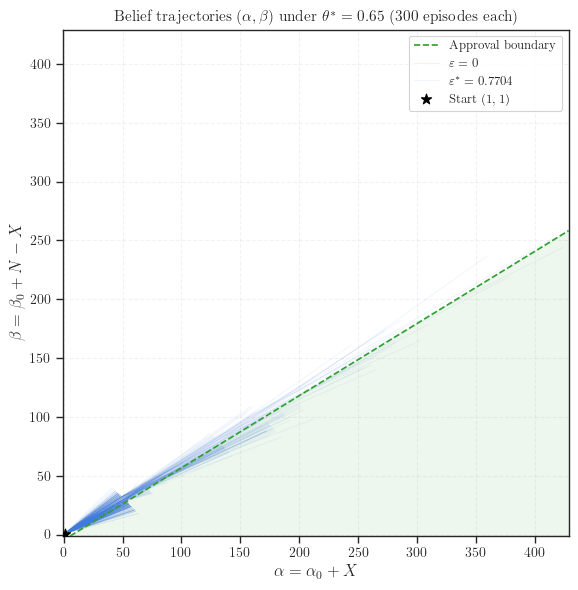

In [11]:
# ── Belief trajectories in (α, β) space: eps=0 (black) vs eps* (blue) ─────────
#
# Each trajectory starts at (α₀, β₀) and evolves as
#     α ← α + x,   β ← β + (n − x)   where x ~ Bin(n, theta_star).
# The approval boundary is the line where the rejection condition holds with equality.
# ── Configure ──────────────────────────────────────────────────────────────────
n_traj_plot = 300    # trajectories per policy
seed_traj   = 7
# ──────────────────────────────────────────────────────────────────────────────

import yaml
with open('../../config/costly.yaml') as f:
    _cfg_traj = yaml.safe_load(f)
_theta_star_traj = float(_cfg_traj['theta_star'])

_alpha_0       = float(params['alpha_0'])
_beta_0        = float(params['beta_0'])
_T             = int(params['T'])
_log_kappa_inv = np.log(1.0 / float(params['kappa']))
_log_term      = np.log(1.0 + float(params['theta_b']) * (np.e - 1.0))

def _approved_NX(N, X):
    return X - N * _log_term >= _log_kappa_inv

def _simulate_ab_trajectory(policy, theta_star, rng):
    alpha, beta = _alpha_0, _beta_0
    path   = [(alpha, beta)]
    N, X   = 0, 0
    status = 'timeout'
    for l in range(_T + 1):
        n_star = int(policy[l][N, X])
        if n_star == 0:
            status = 'optout'; break
        x     = int(rng.binomial(n_star, theta_star))
        N    += n_star;  X += x
        alpha = _alpha_0 + X
        beta  = _beta_0  + N - X
        path.append((alpha, beta))
        if _approved_NX(N, X):
            status = 'approved'; break
    return path, status

# ── Simulate ───────────────────────────────────────────────────────────────────
_rng = np.random.default_rng(seed_traj)

_policies_to_plot = [
    (policy_per_bp_list[0],  epsilons[0],   'red',    r'$\varepsilon = 0$'),
    (policy_per_bp_list[11], epsilons[11],  "#407BDB",  rf'$\varepsilon^* = {epsilons[11]:.4f}$'),
]

_all_paths = {}
for pol, eps_val, color, lbl in _policies_to_plot:
    trajs = [_simulate_ab_trajectory(pol, _theta_star_traj, _rng)
             for _ in range(n_traj_plot)]
    _all_paths[eps_val] = (trajs, color, lbl)

# ── Axis limits ────────────────────────────────────────────────────────────────
_all_a = [pt[0] for (trajs, _, __) in _all_paths.values() for p, _ in trajs for pt in p]
_all_b = [pt[1] for (trajs, _, __) in _all_paths.values() for p, _ in trajs for pt in p]
_lo = min(min(_all_a), min(_all_b)) - 2
_hi = max(max(_all_a), max(_all_b)) + 5

# ── Approval boundary ──────────────────────────────────────────────────────────
_alpha_line = np.linspace(_lo, _hi, 600)
_beta_bnd   = (
    (1 - _log_term) * _alpha_line
    + _log_term * (_alpha_0 + _beta_0)
    - _alpha_0
    - _log_kappa_inv
) / _log_term

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

ax.fill_between(_alpha_line, _beta_bnd, _lo,
                where=(_beta_bnd >= _lo),
                color='#2ca02c', alpha=0.08)
ax.plot(_alpha_line, _beta_bnd, color='#2ca02c', lw=1.2, ls='--',
        label='Approval boundary', zorder=4)

for eps_val, (trajs, color, lbl) in _all_paths.items():
    _first = True
    for path, status in trajs:
        alphas = [pt[0] for pt in path]
        betas  = [pt[1] for pt in path]
        ax.plot(alphas, betas, color=color, alpha=0.08, lw=0.7, zorder=2,
                label=lbl if _first else None)
        _first = False

ax.scatter([_alpha_0], [_beta_0], color='black', s=60, zorder=6,
           marker='*', label=rf'Start $({_alpha_0:.0f},{_beta_0:.0f})$')

ax.set_xlim(_lo, _hi);  ax.set_ylim(_lo, _hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$\alpha = \alpha_0 + X$',  fontsize=12)
ax.set_ylabel(r'$\beta  = \beta_0  + N - X$', fontsize=12)
ax.set_title(
    rf'Belief trajectories $(\alpha, \beta)$ under $\theta^* = {_theta_star_traj}$'
    f'  ({n_traj_plot} episodes each)',
    fontsize=11
)
ax.legend(fontsize=9, loc='upper right', framealpha=0.85)
ax.grid(True, linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()
fig.savefig('../../figures/costly/mdp_output/belief_trajectories_ab_space.pdf',
            format='pdf', bbox_inches='tight')


MC evaluation (true agent): theta* = 0.65,  100,000 episodes per policy

  [ 0] eps=0.000000  P=0.0000  V0_true=0.00  A_true=0.0000
  [ 1] eps=0.551124  P=0.7733  V0_true=28.60  A_true=125.1739
  [ 2] eps=0.585204  P=0.7734  V0_true=28.51  A_true=125.2521
  [ 3] eps=0.604167  P=0.7734  V0_true=28.51  A_true=125.2980
  [ 4] eps=0.638290  P=0.7755  V0_true=28.54  A_true=126.0391
  [ 5] eps=0.648226  P=0.7744  V0_true=27.82  A_true=126.2518
  [ 6] eps=0.657006  P=0.7761  V0_true=27.91  A_true=126.8585
  [ 7] eps=0.748834  P=0.7762  V0_true=27.88  A_true=126.9376
  [ 8] eps=0.753799  P=0.7759  V0_true=27.48  A_true=127.0807
  [ 9] eps=0.757709  P=0.7760  V0_true=27.49  A_true=127.1020
  [10] eps=0.764306  P=0.7761  V0_true=27.51  A_true=127.1279
  [11] eps=0.770370  P=0.7762  V0_true=27.51  A_true=127.1859
  [12] eps=0.783866  P=0.7779  V0_true=27.59  A_true=127.8642
  [13] eps=0.790928  P=0.7799  V0_true=27.80  A_true=128.5640
  [14] eps=0.827376  P=0.7800  V0_true=27.80  A_true=128.6037


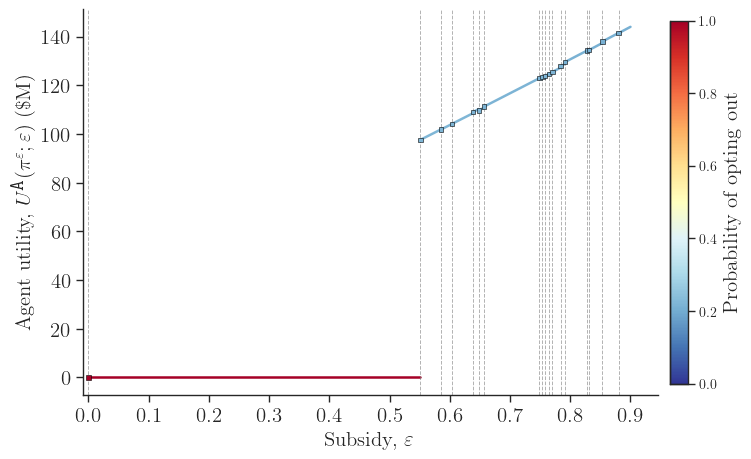

In [25]:
# ── True agent utility V_true*(eps) via Monte Carlo rollout under theta_star ────
#
# Within interval [eps_i, eps_{i+1}), policy pi_i is optimal.  We roll it out
# under the TRUE efficacy theta_star and decompose the agent's expected payoff:
#
#   V_true*(eps; pi_i) = V0_true_i + eps * A_true_i
#
# where:
#   A_true_i  = E_true[C * 1{approved}]   (same definition as in the MDP)
#   V0_true_i = rho_A * P_true_i - E_true[C_all]   (agent value at eps=0)
#   E_true[C_all] = expected total cost regardless of approval outcome
#
# ── Configure ────────────────────────────────────────────────────────────────────────────
import yaml
config_path = '../../config/costly.yaml'
n_ep_agent  = 100_000   # MC episodes per policy
seed_agent  = 42
# ──────────────────────────────────────────────────────────────────────────────

with open(config_path) as f:
    _cfg_agent = yaml.safe_load(f)
theta_star_agent = float(_cfg_agent['theta_star'])

rho_A_agent   = float(params['rho_A'])
policy_per_bp = res['policy_per_breakpoint']

def _mc_agent(policy, theta_star, params, n_episodes, seed):
    """MC rollout under theta_star.  Returns (p_approval, e_cost_all, e_cost_approved)."""
    rng           = np.random.default_rng(seed)
    T             = int(params['T'])
    c0_           = float(params['c0'])
    c1_           = float(params['c1'])
    alpha_0       = float(params['alpha_0'])
    beta_0        = float(params['beta_0'])
    log_kappa_inv = np.log(1.0 / float(params['kappa']))
    log_term      = np.log(1.0 + float(params['theta_b']) * (np.e - 1.0))

    def _rejected(N, X):
        alpha = alpha_0 + X
        beta  = beta_0  + N - X
        return (alpha - alpha_0) - (alpha + beta - alpha_0 - beta_0) * log_term >= log_kappa_inv

    n_approved        = 0
    sum_cost_approved = 0.0
    sum_cost_all      = 0.0

    for _ in range(n_episodes):
        N, X, C, approved = 0, 0, 0.0, False
        for l in range(T + 1):
            n_star = int(policy[l][N, X])
            if n_star == 0:
                break
            C += c0_ + c1_ * n_star
            x  = int(rng.binomial(n_star, theta_star))
            N += n_star; X += x
            if _rejected(N, X):
                approved = True
                break
        sum_cost_all += C
        if approved:
            n_approved        += 1
            sum_cost_approved += C

    p           = n_approved / n_episodes
    e_cost_all  = sum_cost_all / n_episodes
    e_cost_appr = sum_cost_approved / n_episodes   # = E[C * 1{approved}]
    return p, e_cost_all, e_cost_appr

print(f"MC evaluation (true agent): theta* = {theta_star_agent},  {n_ep_agent:,} episodes per policy\n")

true_agent_P, true_agent_V0, true_agent_A = [], [], []
for i, (eps_i, policy) in enumerate(zip(epsilons, policy_per_bp)):
    p, ec_all, ec_appr = _mc_agent(policy, theta_star_agent, params, n_ep_agent, seed_agent)
    v0_true = rho_A_agent * p - ec_all
    true_agent_P.append(p)
    true_agent_V0.append(v0_true)
    true_agent_A.append(ec_appr)
    print(f"  [{i:2d}] eps={eps_i:.6f}  P={p:.4f}  V0_true={v0_true:.2f}  A_true={ec_appr:.4f}")

sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

import matplotlib.colors as _mcolors
import matplotlib.cm as _cm
_cmap_ta  = matplotlib.colormaps['RdYlBu_r']
_norm_ta  = _mcolors.Normalize(vmin=min(true_optout_list), vmax=max(true_optout_list))
_norm_ta = _mcolors.Normalize(vmin=0.0, vmax=1.0)
seg_colors = [_cmap_ta(_norm_ta(p)) for p in true_optout_list]
palette    = sns.color_palette('tab10')

for i in range(len(epsilons)):
    eps_left  = epsilons[i]
    eps_right = epsilons[i + 1] if i + 1 < len(epsilons) else epsilon_max
    eps_seg   = np.linspace(eps_left, eps_right, N_SAMPLE)
    v_seg     = true_agent_V0[i] + eps_seg * true_agent_A[i]
    ax.plot(eps_seg, v_seg, color=seg_colors[i], lw=1.8)



# Vertical dashed lines at each partition breakpoint
for eps_i in epsilons:
    ax.axvline(eps_i, color='gray', lw=0.7, ls='--', alpha=0.6)

# Kink points
kink_v_true = [true_agent_V0[i] + epsilons[i] * true_agent_A[i] for i in range(len(epsilons))]
ax.scatter(epsilons, kink_v_true,
           color=[seg_colors[i] for i in range(len(epsilons))],
           s=10, zorder=5, edgecolors='black', linewidths=0.4, marker='s')

# Mark eps*
star_idx    = epsilons.index(eps_star)
v_star_true = true_agent_V0[star_idx] + eps_star * true_agent_A[star_idx]





ax.set_xticks(epsilons)
ax.set_xlabel(r'Subsidy, $\varepsilon$', fontsize=15)
ax.set_ylabel(r"Agent utility, $U^{\texttt{A}}(\pi^{\varepsilon};\varepsilon)$ (\$M)", fontsize=15)

#set yticks fontsize
ax.tick_params(axis='y', labelsize=15)

ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)
_sm_ta = _cm.ScalarMappable(cmap=_cmap_ta, norm=_norm_ta)
_sm_ta.set_array([])
_cb_ta = fig.colorbar(_sm_ta, ax=ax, pad=0.02, fraction=0.03)
_cb_ta.set_label(r'Probability of opting out', fontsize=15)

_cb.set_ticks(np.arange(0.0, 1.01, 0.2))
_cb.set_ticklabels([f"{t:.1f}" for t in np.arange(0.0, 1.01, 0.2)])
_cb.ax.tick_params(labelsize=15)



_step   = 0.1
_xticks = np.arange(0.0, epsilon_max + _step, _step)
_xticks = _xticks[_xticks <= epsilon_max + 1e-9]
ax.set_xticks(_xticks)
ax.set_xticklabels([f'{t:.1f}' for t in _xticks], fontsize=15)
ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)

sns.despine()
plt.tight_layout()
plt.show()

os.makedirs('../../figures/costly/mdp_output', exist_ok=True)

fig.savefig('../../figures/costly/mdp_output/true_agent_value_vs_epsilon.pdf',
            format='pdf', bbox_inches='tight')


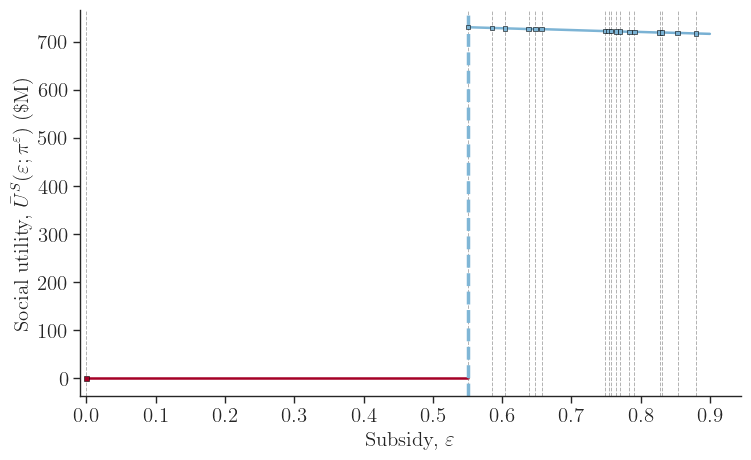

In [27]:
# ── Social utility U^S(eps) = rho_S * P_i - eps * A_i ────────────────────────

sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 1000
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

palette    = sns.color_palette('tab10')
import matplotlib.colors as _mcolors
import matplotlib.cm as _cm
_cmap_us   = matplotlib.colormaps['RdYlBu_r']
_norm_us   = _mcolors.Normalize(vmin=min(true_optout_list), vmax=max(true_optout_list))
_norm_us = _mcolors.Normalize(vmin=0.0, vmax=1.0)
seg_colors = [_cmap_us(_norm_us(p)) for p in true_optout_list]

for i, (eps_seg, us_seg, label) in enumerate(segments):
    ax.plot(eps_seg, us_seg, color=seg_colors[i], lw=1.8)

for eps_i in epsilons:
    ax.axvline(eps_i, color='gray', lw=0.7, ls='--', alpha=0.6)

ax.scatter(epsilons, social_utilities,
           color=[seg_colors[i] for i in range(len(epsilons))],
           s=10, zorder=5, edgecolors='black', linewidths=0.4, marker='s')

ax.axvline(eps_star, color=seg_colors[star_idx] ,lw=2.5, ls='--',
           label=f'$\\varepsilon^* = {eps_star:.4f}$')


ax.set_xticks(epsilons)

ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)
ax.set_xlabel(r'Subsidy, $\varepsilon$', fontsize=15)
ax.set_ylabel(r'Social utility, $\bar{U}^S(\varepsilon; \pi^{\varepsilon})$ (\$M)' , fontsize=15)



# _sm_us = _cm.ScalarMappable(cmap=_cmap_us, norm=_norm_us)
# _sm_us.set_array([])
# _cb_us = fig.colorbar(_sm_us, ax=ax, pad=0.02, fraction=0.03)
# _cb_us.set_label(r'Probability of opting out', fontsize=15)
# _cb_us.ax.tick_params(labelsize=15)


_step   = 0.1
_xticks = np.arange(0.0, epsilon_max + _step, _step)
_xticks = _xticks[_xticks <= epsilon_max + 1e-9]
ax.set_xticks(_xticks)
ax.set_xticklabels([f'{t:.1f}' for t in _xticks], fontsize=15)
ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)

ax.tick_params(axis='y', labelsize=15)

sns.despine()
plt.tight_layout()
plt.show()

os.makedirs('../../figures/costly/mdp_output', exist_ok=True)
plt.rcParams['savefig.bbox'] = 'standard'
fig.set_size_inches(fig_width, fig_height)
fig.savefig('../../figures/costly/mdp_output/social_utility_vs_epsilon.pdf',
            format='pdf', bbox_inches='tight')


In [18]:
# ── True social utility via Monte Carlo rollout under theta_star ───────────────
#
# Policy pi_i is constant on [eps_i, eps_{i+1}).  We roll it out under the TRUE
# efficacy theta_star (drawing X_t ~ Bin(n_t, theta_star), not Beta-Binomial) to
# get empirical P_true(approval | pi_i, theta*) and A_true = E[cost | approval].
# True social utility on interval i:
#
#   U^S_true(eps; pi_i) = rho_S * P_true_i  -  eps * A_true_i     (linear in eps)
#
# ── Configure ──────────────────────────────────────────────────────────────────
import yaml
config_path = '../../config/costly.yaml'
n_episodes  = 100_000     # Monte Carlo episodes per policy evaluation
seed        = 42
# ──────────────────────────────────────────────────────────────────────────────

with open(config_path) as f:
    _cfg = yaml.safe_load(f)
theta_star = float(_cfg['theta_star'])

print(f"Loaded theta_star = {theta_star} from {config_path}")

policy_per_breakpoint = res['policy_per_breakpoint']

def _mc_evaluate(policy, theta_star, params, n_episodes, seed):
    """Roll out policy under theta_star. Returns (p_approval, e_cost_given_approval)."""
    rng         = np.random.default_rng(seed)
    T           = int(params['T'])
    c0          = float(params['c0'])
    c1          = float(params['c1'])
    alpha_0     = float(params['alpha_0'])
    beta_0      = float(params['beta_0'])
    log_kappa_inv = np.log(1.0 / float(params['kappa']))
    log_term      = np.log(1.0 + float(params['theta_b']) * (np.e - 1.0))

    def _rejected(N, X):
        alpha = alpha_0 + X
        beta  = beta_0  + N - X
        return (alpha - alpha_0) - (alpha + beta - alpha_0 - beta_0) * log_term >= log_kappa_inv

    n_approved, sum_cost = 0, 0.0
    for _ in range(n_episodes):
        N, X, C, approved = 0, 0, 0.0, False
        for l in range(T + 1):
            n_star = int(policy[l][N, X])
            if n_star == 0:
                break
            C += c0 + c1 * n_star
            x  = int(rng.binomial(n_star, theta_star))
            N += n_star;  X += x
            if _rejected(N, X):
                approved = True
                break
        if approved:
            n_approved += 1
            sum_cost   += C

    p = n_approved / n_episodes
    a =  sum_cost / n_episodes   # E[C_total * 1{approval}], consistent with MDP A definition
    return p, a

print(f"MC evaluation: theta* = {theta_star},  {n_episodes:,} episodes per policy\n")

true_P_list, true_A_list = [], []
for i, (eps_i, policy) in enumerate(zip(epsilons, policy_per_breakpoint)):
    p, a = _mc_evaluate(policy, theta_star, params, n_episodes, seed)
    true_P_list.append(p)
    true_A_list.append(a)
    us = rho_S * p - eps_i * a
    print(f"  [{i:2d}] eps={eps_i:.8f}  P_true={p:.4f}  A_true(E[C*1{{approved}}])={a:.4f}  U^S_true={us:.4f}")

# True social utility at each breakpoint (left endpoint of each interval)
true_US_breakpoints = [rho_S * p - eps * a
                       for eps, p, a in zip(epsilons, true_P_list, true_A_list)]

valid         = [(i, u) for i, u in enumerate(true_US_breakpoints) if not np.isnan(u)]
best_true_i   = max(valid, key=lambda x: x[1])[0]
eps_star_true = epsilons[best_true_i]
us_star_true  = true_US_breakpoints[best_true_i]

print(f"\nTrue optimal subsidy : eps*_true = {eps_star_true:.8f}  U^S = {us_star_true:.4f}")
print(f"MDP  optimal subsidy : eps*_mdp  = {eps_star:.8f}  U^S = {us_star:.4f}")


Loaded theta_star = 0.65 from ../../config/costly.yaml
MC evaluation: theta* = 0.65,  100,000 episodes per policy

  [ 0] eps=0.00000000  P_true=0.0000  A_true(E[C*1{approved}])=0.0000  U^S_true=0.0000
  [ 1] eps=0.55112414  P_true=0.7733  A_true(E[C*1{approved}])=125.1739  U^S_true=1477.5536
  [ 2] eps=0.58520444  P_true=0.7734  A_true(E[C*1{approved}])=125.2521  U^S_true=1473.4819
  [ 3] eps=0.60416667  P_true=0.7734  A_true(E[C*1{approved}])=125.2980  U^S_true=1471.1591
  [ 4] eps=0.63828963  P_true=0.7755  A_true(E[C*1{approved}])=126.0391  U^S_true=1470.5106
  [ 5] eps=0.64822622  P_true=0.7744  A_true(E[C*1{approved}])=126.2518  U^S_true=1466.9802
  [ 6] eps=0.65700553  P_true=0.7761  A_true(E[C*1{approved}])=126.8585  U^S_true=1468.8733
  [ 7] eps=0.74883359  P_true=0.7762  A_true(E[C*1{approved}])=126.9376  U^S_true=1457.3048
  [ 8] eps=0.75379939  P_true=0.7759  A_true(E[C*1{approved}])=127.0807  U^S_true=1456.0666
  [ 9] eps=0.75770925  P_true=0.7760  A_true(E[C*1{approved}])

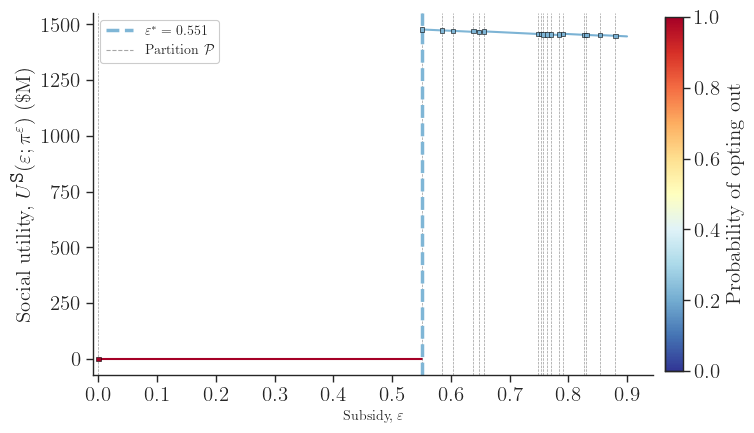

In [24]:

# ── Plot: True social utility ─────────────────────────────────────────────────
#
# Segments are coloured by the TRUE opt-out probability before approval
# (computed in the 'optout_true_cell' above as true_optout_list).
# A darker colour (higher opt-out prob) means the agent is more likely to
# abandon the experiment before reaching the approval threshold.

sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 1000
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

palette  = sns.color_palette('tab10')

# ── Colour map: true opt-out probability ──────────────────────────────────────
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

_cmap    = matplotlib.colormaps['RdYlBu_r']
_p_min   = min(true_optout_list)
_p_max   = max(true_optout_list)
_norm    = _mcolors.Normalize(vmin=_p_min, vmax=_p_max)
_norm = _mcolors.Normalize(vmin=0.0, vmax=1.0)
seg_colors = [_cmap(_norm(p)) for p in true_optout_list]

# ── Piecewise-linear segments ─────────────────────────────────────────────────
for i in range(len(epsilons)):
    eps_left  = epsilons[i]
    eps_right = epsilons[i + 1] if i + 1 < len(epsilons) else epsilon_max
    eps_seg   = np.linspace(eps_left, eps_right, 200)

    P_true_i, A_true_i = true_P_list[i], true_A_list[i]
    us_seg = rho_S * P_true_i - eps_seg * A_true_i
    ax.plot(eps_seg, us_seg, color=seg_colors[i], lw=1.5, ls='-')

# Breakpoint dots
ax.scatter(epsilons, true_US_breakpoints,
           color=seg_colors,
           s=10, zorder=5, edgecolors='black', linewidths=0.4, marker='s')

# Partition verticals
for eps_i in epsilons:
    ax.axvline(eps_i, color='gray', lw=0.5, ls='--', alpha=0.8)
# Proxy artist for the partition legend entry
from matplotlib.lines import Line2D as _Line2D
_partition_handle = _Line2D([0], [0], color='gray', lw=0.8, ls='--', alpha=0.7,
                            label=r'Partition $\mathcal{P}$')

# MDP optimal subsidy — colour matches the interval containing eps_star
mdp_star_idx = epsilons.index(eps_star)
eps_star_color = seg_colors[mdp_star_idx]
us_at_eps_star_mdp = rho_S * true_P_list[mdp_star_idx] - eps_star * true_A_list[mdp_star_idx]
ax.axvline(eps_star, color=eps_star_color, lw=2.5, ls='--',
           label=f'$\\varepsilon^*={eps_star:.3f}$')
#ax.scatter([eps_star], [us_at_eps_star_mdp], color=eps_star_color, s=60, zorder=7,  edgecolors='black', linewidths=0.7, marker='o')

# True optimal subsidy
# ax.axvline(eps_star_true, color=palette[1], lw=1.2, ls='-.',
#            label=f'$\\varepsilon^*_{{\\mathrm{{true}}}}={eps_star_true:.3f}$')
# ax.scatter([eps_star_true], [us_star_true], color=palette[1], s=60, zorder=7,
#            edgecolors='black', linewidths=0.7, marker='s')

# ── x-axis ticks: equi-spaced at 0, 0.1, 0.2, ... ──────────────────────────
_step   = 0.1
_xticks = np.arange(0.0, epsilon_max + _step, _step)
_xticks = _xticks[_xticks <= epsilon_max + 1e-9]
ax.set_xticks(_xticks)
ax.set_xticklabels([f'{t:.1f}' for t in _xticks], fontsize=15)

ax.tick_params(axis='both', labelsize=15)


ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)
ax.set_xlabel(r'Subsidy, $\varepsilon$', fontsize=10)
ax.set_ylabel(r'Social utility, $U^{\texttt{S}}(\varepsilon;\pi^{\varepsilon})$ (\$M)', fontsize=15)
ax.legend(handles=ax.get_legend_handles_labels()[0] + [_partition_handle],
          fontsize=10, framealpha=1, loc='upper left')


# Colourbar
_sm = _cm.ScalarMappable(cmap=_cmap, norm=_norm)
_sm.set_array([])
_cb = fig.colorbar(_sm, ax=ax, pad=0.02, fraction=0.03)
_cb.set_label(r'Probability of opting out', fontsize=15)
_cb.ax.tick_params(labelsize=10)

_cb.set_ticks(np.arange(0.0, 1.01, 0.2))
_cb.set_ticklabels([f"{t:.1f}" for t in np.arange(0.0, 1.01, 0.2)])
_cb.ax.tick_params(labelsize=15)


sns.despine()
#plt.tight_layout()
plt.show()


fig_dir = '../../figures/costly/mdp_output'
os.makedirs(fig_dir, exist_ok=True)

out_path = os.path.join(fig_dir, 'true_social_utility.pdf')
#plt.rcParams['savefig.bbox'] = 'standard'
fig.set_size_inches(fig_width, fig_height)
fig.subplots_adjust(
    left=0.12,
    right=0.88,   # leave space for colorbar in Code 2
    top=0.95,
    bottom=0.15
)
fig.savefig(out_path, format='pdf')


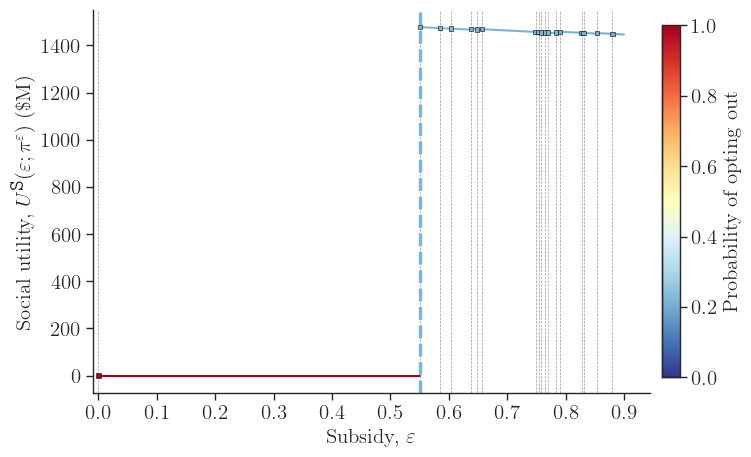

In [ ]:
# ── Plot: True social utility ─────────────────────────────────────────────────
#
# Segments are coloured by the TRUE opt-out probability before approval
# (computed in the 'optout_true_cell' above as true_optout_list).
# A darker colour (higher opt-out prob) means the agent is more likely to
# abandon the experiment before reaching the approval threshold.

sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 1000
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

palette  = sns.color_palette('tab10')

# ── Colour map: true opt-out probability ──────────────────────────────────────
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

_cmap    = matplotlib.colormaps['RdYlBu_r']
_p_min   = min(true_optout_list)
_p_max   = max(true_optout_list)
_norm    = _mcolors.Normalize(vmin=_p_min, vmax=_p_max)
_norm = _mcolors.Normalize(vmin=0.0, vmax=1.0)
seg_colors = [_cmap(_norm(p)) for p in true_optout_list]

# ── Piecewise-linear segments ─────────────────────────────────────────────────
for i in range(len(epsilons)):
    eps_left  = epsilons[i]
    eps_right = epsilons[i + 1] if i + 1 < len(epsilons) else epsilon_max
    eps_seg   = np.linspace(eps_left, eps_right, 200)

    P_true_i, A_true_i = true_P_list[i], true_A_list[i]
    us_seg = rho_S * P_true_i - eps_seg * A_true_i
    ax.plot(eps_seg, us_seg, color=seg_colors[i], lw=1.5, ls='-')

# Breakpoint dots
ax.scatter(epsilons, true_US_breakpoints,
           color=seg_colors,
           s=10, zorder=5, edgecolors='black', linewidths=0.4, marker='s')

# Partition verticals
for eps_i in epsilons:
    ax.axvline(eps_i, color='gray', lw=0.5, ls='--', alpha=0.8)
# Proxy artist for the partition legend entry
from matplotlib.lines import Line2D as _Line2D
_partition_handle = _Line2D([0], [0], color='gray', lw=0.8, ls='--', alpha=0.7,
                            label=r'Partition $\mathcal{P}$')

# MDP optimal subsidy — colour matches the interval containing eps_star
mdp_star_idx = epsilons.index(eps_star)
eps_star_color = seg_colors[mdp_star_idx]
us_at_eps_star_mdp = rho_S * true_P_list[mdp_star_idx] - eps_star * true_A_list[mdp_star_idx]
ax.axvline(eps_star, color=eps_star_color, lw=2.5, ls='--',
           label=f'$\\varepsilon^*={eps_star:.3f}$')


#ax.scatter([eps_star], [us_at_eps_star_mdp], color=eps_star_color, s=60, zorder=7,  edgecolors='black', linewidths=0.7, marker='o')

# True optimal subsidy
# ax.axvline(eps_star_true, color=palette[1], lw=1.2, ls='-.',
#            label=f'$\\varepsilon^*_{{\\mathrm{{true}}}}={eps_star_true:.3f}$')
# ax.scatter([eps_star_true], [us_star_true], color=palette[1], s=60, zorder=7,
#            edgecolors='black', linewidths=0.7, marker='s')

# ── x-axis ticks: equi-spaced at 0, 0.1, 0.2, ... ──────────────────────────
_step   = 0.1
_xticks = np.arange(0.0, epsilon_max + _step, _step)
_xticks = _xticks[_xticks <= epsilon_max + 1e-9]
ax.set_xticks(_xticks)
ax.set_xticklabels([f'{t:.1f}' for t in _xticks], fontsize=15)

ax.tick_params(axis='both', labelsize=15)


ax.set_xlim(-0.01 * epsilon_max, 1.05 * epsilon_max)
ax.set_xlabel(r'Subsidy, $\varepsilon$', fontsize=15)
ax.set_ylabel(r'Social utility, $U^{\texttt{S}}(\varepsilon;\pi^{\varepsilon})$ (\$M)', fontsize=15)


# Colourbar
_sm = _cm.ScalarMappable(cmap=_cmap, norm=_norm)
_sm.set_array([])
_cb = fig.colorbar(_sm, ax=ax, pad=0.02, fraction=0.03)
_cb.set_label(r'Probability of opting out', fontsize=15)

_cb.set_ticks(np.arange(0.0, 1.01, 0.2))
_cb.set_ticklabels([f"{t:.1f}" for t in np.arange(0.0, 1.01, 0.2)])
_cb.ax.tick_params(labelsize=15)

sns.despine()
plt.tight_layout()
plt.show()


fig_dir = '../../figures/costly/mdp_output'
os.makedirs(fig_dir, exist_ok=True)

out_path = os.path.join(fig_dir, 'true_social_utility_app.pdf')

fig.savefig(out_path, format='pdf', bbox_inches='tight')
